# KXHIGH Weather Contracts - Historical Volume & Open Interest

Displays historical volume and open_interest data for all 20 cities' temperature contracts,
sampled every 30 minutes from 4pm-8pm local time, since Jan 1, 2026.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

DATA_FILE = os.path.join("neural-net", "data", "kalshi_markets", "historical_volume.csv")

if not os.path.exists(DATA_FILE):
    print(f"Data file not found: {DATA_FILE}")
    print("Run: python backfill_kalshi.py")
else:
    df = pd.read_csv(DATA_FILE, parse_dates=["snapshot_ts"])
    df["local_time_parsed"] = pd.to_datetime(df["local_time"])
    df["local_hour"] = df["local_time_parsed"].dt.hour + df["local_time_parsed"].dt.minute / 60
    print(f"Loaded {len(df)} rows, {df['city'].nunique()} cities, "
          f"{df['date'].nunique()} days")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    df.head()

Loaded 63360 rows, 20 cities, 66 days
Date range: 2026-02-13 to 2026-04-19


## Volume Over Time by City

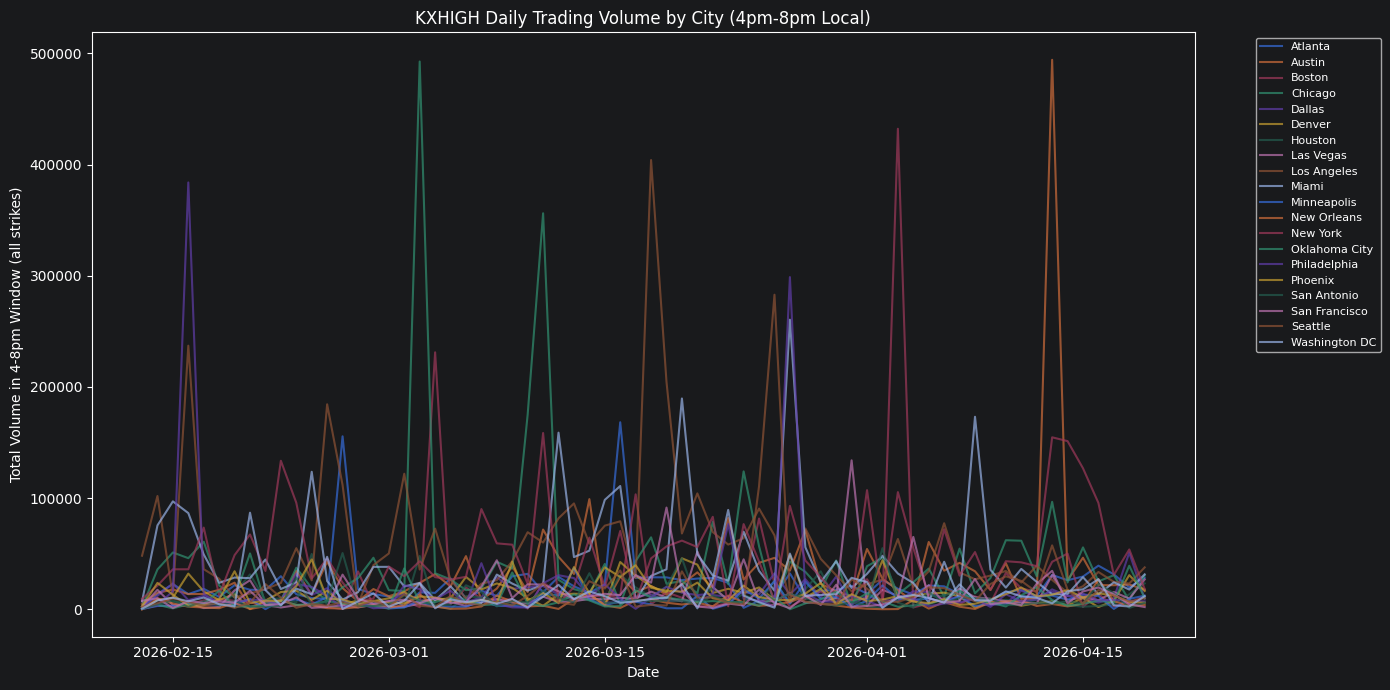

In [12]:
if os.path.exists(DATA_FILE):
    daily_vol = df.groupby(["date", "city"])["volume_in_slot"].sum().reset_index()
    daily_vol["date"] = pd.to_datetime(daily_vol["date"])

    fig, ax = plt.subplots(figsize=(14, 7))
    for city in sorted(daily_vol["city"].unique()):
        city_data = daily_vol[daily_vol["city"] == city]
        ax.plot(city_data["date"], city_data["volume_in_slot"], label=city, alpha=0.7)
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Volume in 4-8pm Window (all strikes)")
    ax.set_title("KXHIGH Daily Trading Volume by City (4pm-8pm Local)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

## Volume Traded at 92-97c Over Time by City

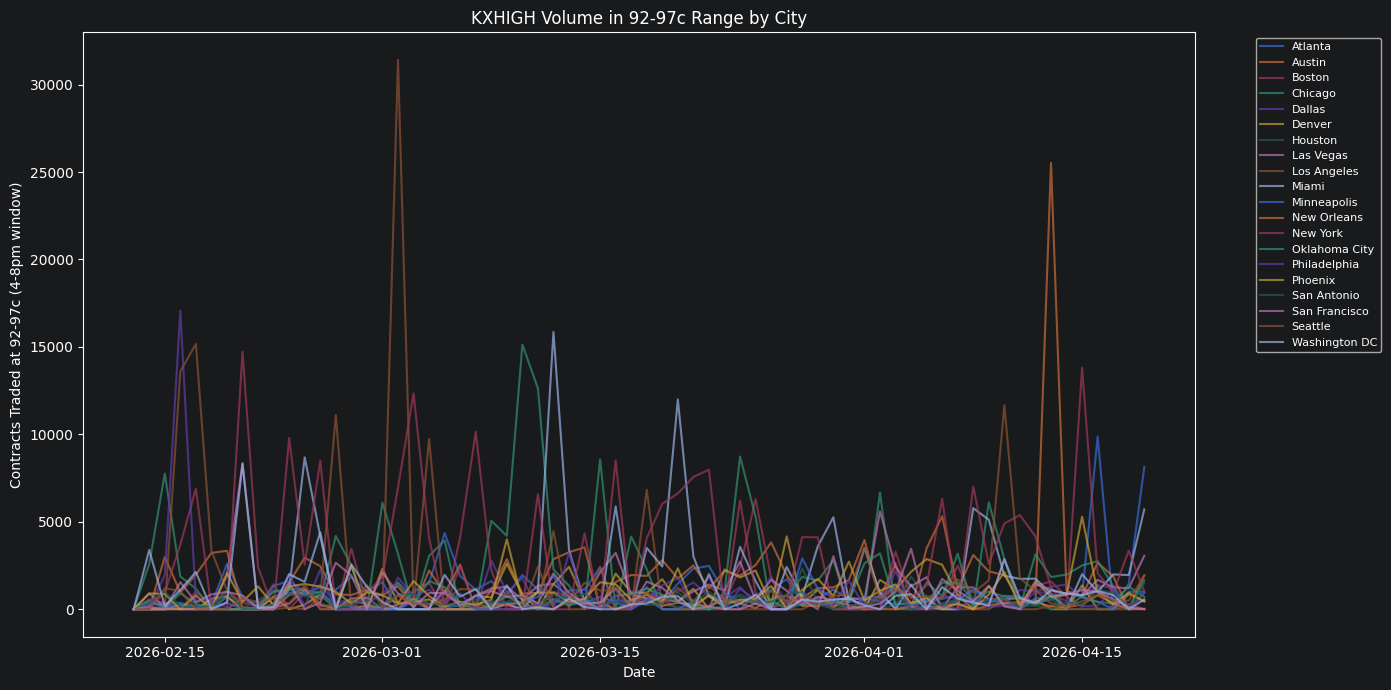

In [13]:
if os.path.exists(DATA_FILE):
    daily_92 = df.groupby(["date", "city"])["volume_92_97"].sum().reset_index()
    daily_92["date"] = pd.to_datetime(daily_92["date"])

    fig, ax = plt.subplots(figsize=(14, 7))
    for city in sorted(daily_92["city"].unique()):
        city_data = daily_92[daily_92["city"] == city]
        ax.plot(city_data["date"], city_data["volume_92_97"], label=city, alpha=0.7)
    ax.set_xlabel("Date")
    ax.set_ylabel("Contracts Traded at 92-97c (4-8pm window)")
    ax.set_title("KXHIGH Volume in 92-97c Range by City")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

## Intraday Pattern: Volume (92-97c) by 30-Minute Slot (4pm - 8pm)

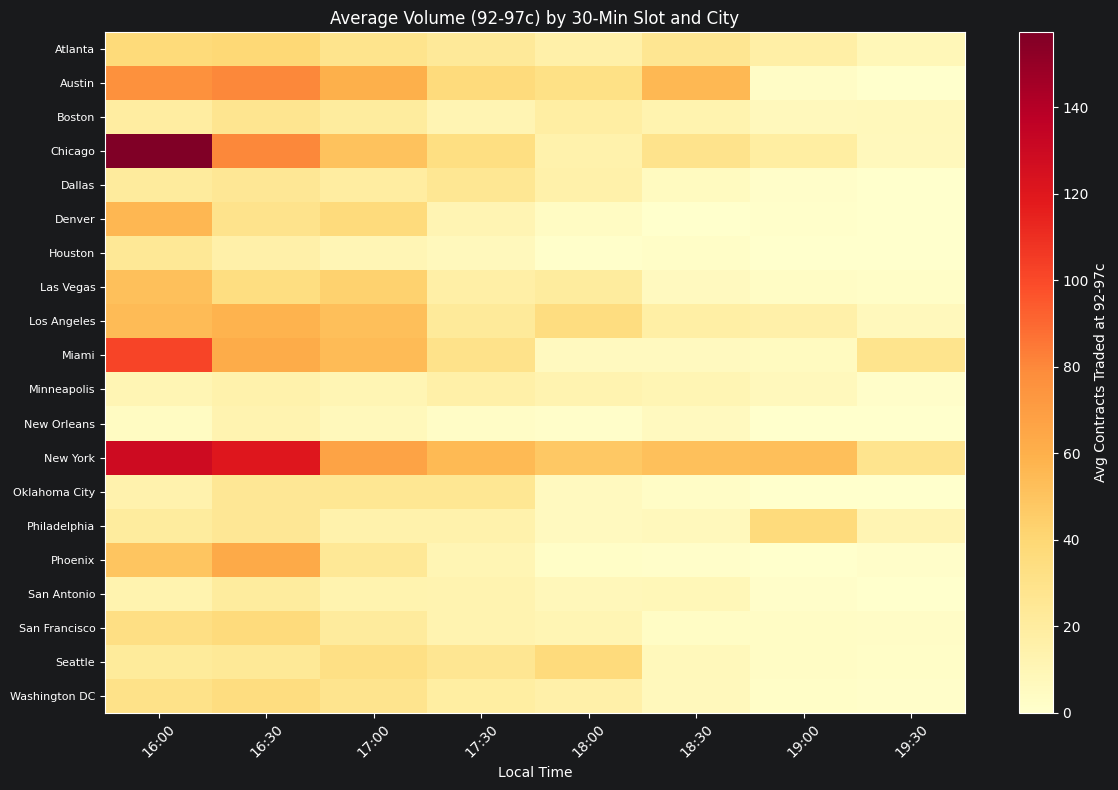

In [14]:
if os.path.exists(DATA_FILE):
    intraday = df.groupby(["local_hour", "city"])["volume_92_97"].mean().reset_index()
    pivot = intraday.pivot(index="local_hour", columns="city", values="volume_92_97")

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(pivot.T.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
    ax.set_xticks(range(len(pivot.index)))
    ax.set_xticklabels([f"{int(h)}:{int((h%1)*60):02d}" for h in pivot.index], rotation=45)
    ax.set_yticks(range(len(pivot.columns)))
    ax.set_yticklabels(pivot.columns, fontsize=8)
    ax.set_xlabel("Local Time")
    ax.set_title("Average Volume (92-97c) by 30-Min Slot and City")
    plt.colorbar(im, ax=ax, label="Avg Contracts Traded at 92-97c")
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [15]:
if os.path.exists(DATA_FILE):
    summary = df.groupby("city").agg(
        total_volume_4to8=("volume_in_slot", "sum"),
        total_volume_92_97=("volume_92_97", "sum"),
        avg_slot_volume=("volume_in_slot", "mean"),
        avg_slot_vol_92_97=("volume_92_97", "mean"),
        max_slot_vol_92_97=("volume_92_97", "max"),
        num_snapshots=("volume_in_slot", "count"),
    ).round(1)

    summary["pct_in_range"] = (
        (summary["total_volume_92_97"] / summary["total_volume_4to8"] * 100)
        .round(1).fillna(0)
    )
    summary = summary.sort_values("total_volume_92_97", ascending=False)

    print(f"Data range: {df['date'].min()} to {df['date'].max()}")
    print(f"Total snapshots: {len(df)}")
    print(f"Cities: {df['city'].nunique()}")
    print()
    summary

Data range: 2026-02-13 to 2026-04-19
Total snapshots: 63360
Cities: 20

